# Data Pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
column_names = [
    "user_id",
    "movie_id",
    "rating",
    "timestamp"
]

train = pd.read_csv(
    "data/u1.base",
    sep="\t",
    names=column_names
)

test = pd.read_csv(
    "data/u1.test",
    sep="\t",
    names=column_names
)

In [3]:
train["user_id"] -= 1
train["movie_id"] -= 1

test["user_id"] -= 1
test["movie_id"] -= 1

In [4]:
num_users = max(
    train["user_id"].max(),
    test["user_id"].max()
) + 1

num_movies = max(
    train["movie_id"].max(),
    test["movie_id"].max()
) + 1

print("Users :", num_users)
print("Movies:", num_movies)

Users : 943
Movies: 1682


In [5]:
class MovieLensDataset(Dataset):

    def __init__(self, ratings):

        self.users = torch.LongTensor(
            ratings["user_id"].values
        )

        self.movies = torch.LongTensor(
            ratings["movie_id"].values
        )

        self.ratings = torch.FloatTensor(
            ratings["rating"].values
        )

    def __len__(self):

        return len(
            self.ratings
        )

    def __getitem__(self, idx):

        return (

            self.users[idx],

            self.movies[idx],

            self.ratings[idx]

        )

In [6]:
train_dataset = MovieLensDataset(
    train
)

test_dataset = MovieLensDataset(
    test
)

C:\Users\miyas\AppData\Local\Temp\ipykernel_26260\195127883.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.users = torch.LongTensor(


In [7]:
train_loader = DataLoader(

    train_dataset,

    batch_size=256,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=256,

    shuffle=False

)

In [8]:
print("Training Samples :", len(train_dataset))
print("Testing Samples  :", len(test_dataset))

Training Samples : 80000
Testing Samples  : 20000


In [9]:
users, movies, ratings = next(
    iter(train_loader)
)

print("Users Shape :", users.shape)
print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)

Users Shape : torch.Size([256])
Movies Shape: torch.Size([256])
Ratings Shape: torch.Size([256])


In [10]:
print(users[:10])

print()

print(movies[:10])

print()

print(ratings[:10])

tensor([710, 290, 319, 577, 824, 494, 428, 708,  23, 267])

tensor([ 342,  654,  121,  345, 1253,  388,  738,  231,  581, 1072])

tensor([3., 4., 3., 3., 1., 5., 3., 5., 4., 4.])


In [14]:
users,users.shape

(tensor([710, 290, 319, 577, 824, 494, 428, 708,  23, 267, 641, 624,  25, 404,
         302, 594, 804, 847,  93, 467, 436, 200,  64, 716, 591, 941, 673, 888,
         292, 373, 813, 310, 451, 639, 386, 789, 744, 687,  81,  25, 922,   9,
         342, 900, 264, 718,   6, 662,  82, 931, 594, 902, 928, 681,  22, 388,
         464, 706, 726,  10, 733, 839, 886, 657, 108, 845, 166, 384, 906, 863,
         621, 881, 746, 911, 719, 776, 491, 444, 575, 522, 394, 748, 362, 624,
         685, 108, 647, 572,  46, 161, 652, 499, 662, 372, 708, 522, 921,  68,
         599, 151, 177, 920, 108, 932, 933, 405, 884, 425, 746, 882, 525, 939,
         892, 436,  51, 811, 869,  18, 319, 520, 453, 761, 486, 406, 448, 552,
         869, 416, 195, 789, 513, 514, 698, 879, 172, 520, 144, 641, 404, 935,
          36, 285, 911, 795,   0, 392, 737, 689, 503, 566, 337, 707, 875, 233,
         457, 531, 268, 183,  37, 621, 229, 567, 245, 935, 438, 491, 900, 912,
         415, 690, 530, 845, 150, 503, 483, 662, 255

In [15]:
movies,movies.shape

(tensor([ 342,  654,  121,  345, 1253,  388,  738,  231,  581, 1072,   82,  750,
          147,   75,  281, 1009,  518,  477,  646,   14,  745,  465,  178,  221,
          179,  199,  750,   64,  110,   97,  200,  529,  946,   90,  469,  257,
          229,  876,  434, 1012,  124,  524,  188,    0, 1015,  219,  639, 1008,
          831,  735,  921,  292,  495,  778,  193,  628,  257,  601,  719,   27,
          741,   21,  367,  167,  789, 1266,  529,  726,  150, 1247,  221,  195,
           62,  615,  886, 1078,  522,  594,   69,  434,  337,  448,  848,  120,
          968,  201,  522,  175,  285,  357, 1027,  754,  107,  576,  230,  581,
          578, 1143,  402,  723,  782,  658,  594,  398,  962,  574,   94, 1203,
         1630,  495,  324,  285,  723,  769,    6,  872,  507,  318,  163,  209,
          192,  245,  258,  520,  267,   85,  252,  505, 1240,  770,   24,  892,
          180,  242,  323,  658,   58,  782, 1428, 1010,   81,  203,  522,  356,
           86,  560,  224,  

In [16]:
ratings,ratings.shape

(tensor([3., 4., 3., 3., 1., 5., 3., 5., 4., 4., 5., 4., 3., 3., 3., 4., 4., 5.,
         5., 4., 4., 4., 3., 4., 5., 4., 3., 4., 2., 5., 2., 3., 5., 4., 3., 3.,
         2., 5., 5., 1., 4., 5., 4., 5., 3., 5., 3., 3., 3., 3., 4., 4., 3., 3.,
         4., 2., 5., 4., 2., 5., 4., 3., 5., 3., 2., 3., 5., 1., 4., 3., 5., 4.,
         3., 3., 5., 2., 4., 2., 5., 5., 4., 3., 2., 3., 5., 5., 3., 3., 3., 3.,
         2., 3., 2., 1., 3., 4., 3., 5., 3., 5., 4., 5., 3., 3., 5., 1., 4., 4.,
         3., 2., 3., 3., 3., 3., 5., 4., 3., 4., 4., 3., 2., 1., 2., 3., 2., 3.,
         4., 4., 3., 4., 4., 1., 3., 2., 5., 4., 1., 4., 1., 4., 1., 3., 4., 4.,
         5., 3., 3., 4., 4., 3., 3., 5., 5., 2., 4., 4., 2., 5., 5., 3., 3., 3.,
         3., 4., 4., 3., 4., 5., 2., 5., 1., 3., 5., 2., 5., 5., 4., 3., 5., 3.,
         4., 3., 2., 3., 2., 4., 4., 2., 3., 4., 2., 5., 5., 2., 3., 5., 3., 3.,
         3., 5., 4., 3., 5., 3., 4., 4., 3., 2., 4., 5., 3., 4., 2., 5., 5., 3.,
         3., 3., 4., 3., 4.,

# Building Model

In [18]:
class NeuralCollaborativeFiltering(nn.Module):

    def __init__(self,num_users,num_movies,embedding_dim=32):

        super().__init__()

        # User Embedding
        self.user_embedding = nn.Embedding(num_users,embedding_dim)

        # Movie Embedding
        self.movie_embedding = nn.Embedding(num_movies,embedding_dim)

        # Multi-Layer Perceptron
        self.mlp = nn.Sequential(nn.Linear(embedding_dim * 2,64),nn.ReLU(),nn.Linear(64,32),nn.ReLU(),nn.Linear(32,16),nn.ReLU(),nn.Linear(16,1))
        
    def forward(
        self,
        users,
        movies
    ):

        user_vector = self.user_embedding(
            users
        )

        movie_vector = self.movie_embedding(
            movies
        )

        x = torch.cat(
            [
                user_vector,
                movie_vector
            ],
            dim=1
        )

        prediction = self.mlp(
            x
        )

        return prediction.squeeze()

In [19]:
model = NeuralCollaborativeFiltering(

    num_users=num_users,

    num_movies=num_movies,

    embedding_dim=32

)

model

NeuralCollaborativeFiltering(
  (user_embedding): Embedding(943, 32)
  (movie_embedding): Embedding(1682, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [20]:
users, movies, ratings = next(
    iter(train_loader)
)

predictions = model(
    users,
    movies
)

print(predictions.shape)

torch.Size([256])


In [22]:
print("Predictions")

print(predictions[:10])

print()

print("Actual Ratings")

print(ratings[:10])

Predictions
tensor([-0.1162, -0.1218, -0.1294, -0.1643, -0.1466, -0.1691, -0.1501, -0.1506,
        -0.1393, -0.1581], grad_fn=<SliceBackward0>)

Actual Ratings
tensor([3., 5., 3., 4., 3., 4., 5., 4., 4., 5.])


In [23]:
# defining the training loop
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001)

def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=20
):

    print("Training Neural Collaborative Filtering...")

    history = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for users, movies, ratings in train_loader:

            optimizer.zero_grad()

            predictions = model(
                users,
                movies
            )

            loss = criterion(
                predictions,
                ratings
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
                * len(ratings)
            )

        epoch_loss = (
            running_loss
            / len(train_loader.dataset)
        )

        history.append(epoch_loss)

        print(
            f"Epoch {epoch+1:2d}/{epochs}"
            f" | Loss = {epoch_loss:.4f}"
        )

    return history

In [24]:
history = train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=20
)

Training Neural Collaborative Filtering...
Epoch  1/20 | Loss = 2.8801
Epoch  2/20 | Loss = 1.0779
Epoch  3/20 | Loss = 0.9842
Epoch  4/20 | Loss = 0.9301
Epoch  5/20 | Loss = 0.8948
Epoch  6/20 | Loss = 0.8705
Epoch  7/20 | Loss = 0.8516
Epoch  8/20 | Loss = 0.8369
Epoch  9/20 | Loss = 0.8257
Epoch 10/20 | Loss = 0.8149
Epoch 11/20 | Loss = 0.8057
Epoch 12/20 | Loss = 0.7966
Epoch 13/20 | Loss = 0.7900
Epoch 14/20 | Loss = 0.7810
Epoch 15/20 | Loss = 0.7748
Epoch 16/20 | Loss = 0.7673
Epoch 17/20 | Loss = 0.7589
Epoch 18/20 | Loss = 0.7541
Epoch 19/20 | Loss = 0.7457
Epoch 20/20 | Loss = 0.7383


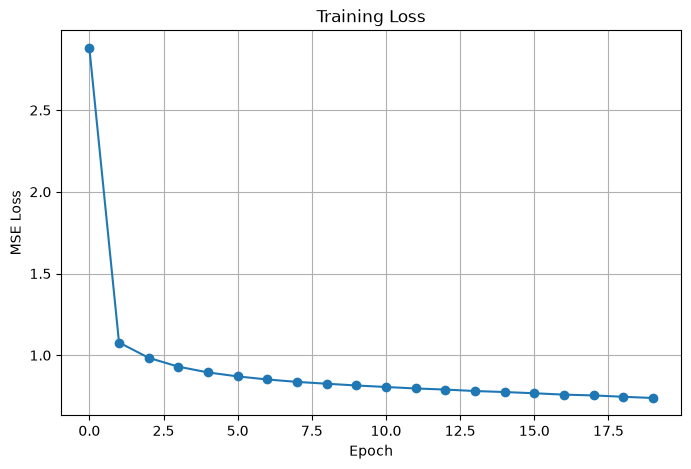

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    history,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

In [26]:
def evaluate(
    model,
    test_loader
):

    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for users, movies, ratings in test_loader:

            outputs = model(
                users,
                movies
            )

            predictions.extend(
                outputs.numpy()
            )

            actuals.extend(
                ratings.numpy()
            )

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mae = np.mean(
        np.abs(
            actuals - predictions
        )
    )

    rmse = np.sqrt(
        np.mean(
            (
                actuals - predictions
            ) ** 2
        )
    )

    prediction_df = pd.DataFrame({

        "actual": actuals,

        "predicted": predictions,

        "error": np.abs(
            actuals - predictions
        )

    })

    return prediction_df, rmse, mae

In [27]:
prediction_df, rmse, mae = evaluate(
    model,
    test_loader
)

print("MAE :", mae)
print("RMSE:", rmse)

prediction_df.head()

MAE : 0.7802626
RMSE: 0.98612857


,actual,predicted,error
0,5.0,4.070921,0.929079
1,3.0,3.792479,0.792479
2,5.0,4.494720,0.505280
3,5.0,4.260761,0.739239
4,3.0,3.534483,0.534483


In [28]:
comparison = pd.DataFrame({

    "Model":[

        "User CF",

        "Item CF",

        "Matrix Factorization",

        "Factorization Machine",

        "Neural Collaborative Filtering"

    ],

    "RMSE":[

        0.9934,

        0.9827,

        0.9540,

        0.9427,

        rmse

    ]

})

comparison.sort_values(
    "RMSE"
)

,Model,RMSE
3,Factorization Machine,0.942700
2,Matrix Factorization,0.954000
1,Item CF,0.982700
4,Neural Collaborative Filtering,0.986129
0,User CF,0.993400


```The Neural Collaborative Filtering implementation did not outperform the Factorization Machine on MovieLens-100K. This is expected because NCF has substantially more trainable parameters and typically requires larger datasets, stronger regularization, validation-based early stopping, and careful hyperparameter tuning. On this relatively small dataset, the simpler Factorization Machine generalized better.```